# Data & Env Initialization

In [1]:
import os, sys, gc

import zipfile
from os import path
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

zip_file = "Lamp-dataset/12Lamp.zip"
data_path = "Lamp-dataset/12Lamp/"

if not path.exists(data_path):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall("Lamp-dataset/")

input_indice_path = data_path + "input_indices_{}.npy"
input_data_path = data_path + "input_data_{}.npy"
target_path = data_path + "output_indices_{}.npy"

# Constants

In [2]:
N_CONFIGURATIONS = 640 # number of data samples
IMG_SHAPE = (1355, 3384, 3)
H, W = 128, 256 # the window size

CAMERA = np.array([[2304.5479, 0,  1686.2379], # the camera matrix
                          [0, 2305.8757, -0.0151],
                          [0, 0, 1.]], dtype=np.float32)

# Data Viz & Utils

In [3]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)
torch.__version__

'2.0.1'

In [4]:
class Sky303Dataset(Dataset):
    """Car dataset."""

    def __init__(self):
        super(Sky303Dataset,self).__init__()

    def __len__(self):
        return 640

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        indice_np = np.load(input_indice_path.format(idx))
        input_np = np.load(input_data_path.format(idx))
        target_np = np.load(target_path.format(idx))
        
        input_bin_mask = np.zeros([H, W, 1], dtype='float16')
        input_bin_mask[indice_np[:,0],indice_np[:,1],:] = 1.
        
        input_2Drepr = np.zeros([H, W, 3], dtype='float16')
        input_2Drepr[indice_np[:,0],indice_np[:,1],:] = input_np
        
        target_2Drepr = np.zeros([H, W, 1], dtype='float16')
        target_2Drepr[target_np[:,0],target_np[:,1],:] = 1.
        
        input_bin_mask = np.rollaxis(input_bin_mask, 2, 0)
        input_bin_mask = torch.from_numpy(input_bin_mask).float()
        
        input_2Drepr = np.rollaxis(input_2Drepr, 2, 0)
        input_2Drepr = torch.from_numpy(input_2Drepr).float()
        
        target_2Drepr = np.rollaxis(target_2Drepr, 2, 0)
        target_2Drepr = torch.from_numpy(target_2Drepr).float()
        
        return [input_bin_mask, input_2Drepr, target_2Drepr]

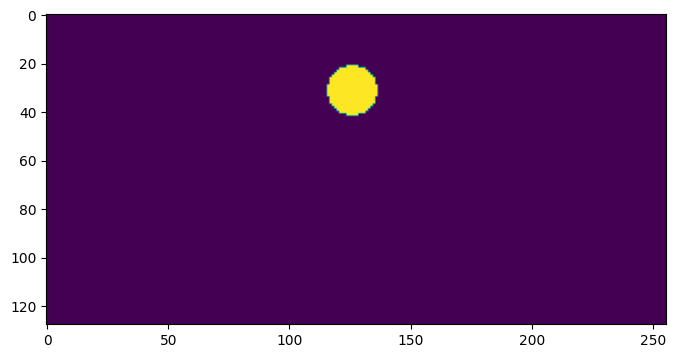

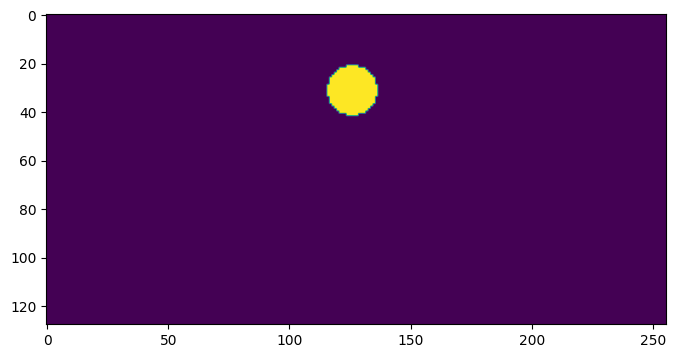

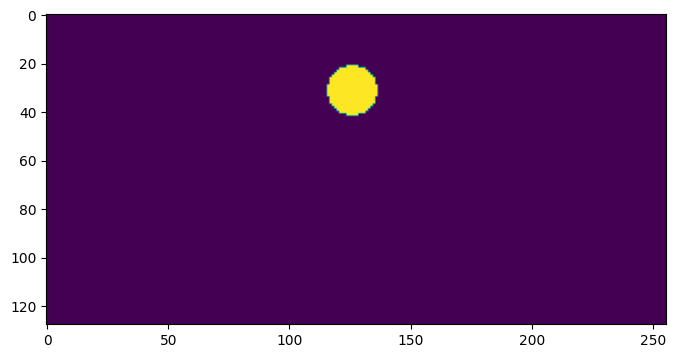

In [5]:
dataset = Sky303Dataset()
input_bin_mask, input_2Drepr, target_2Drepr = dataset[0]

plt.figure(figsize=(8,8))
plt.imshow((input_bin_mask.permute(1,2,0).numpy()[:,:,-1]).squeeze())
plt.show()

plt.figure(figsize=(8,8))
plt.imshow(input_2Drepr.permute(1,2,0).numpy()[:,:,-1]/350.)
plt.show()

plt.figure(figsize=(8,8))
plt.imshow((target_2Drepr.permute(1,2,0).numpy()[:,:,-1]).squeeze())
plt.show()

# Model

In [6]:
import torch.nn as nn
import torch.optim as optim
from smap import *

# Gets the GPU if there is one, otherwise the cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
class SimpleClfNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=2):
        super(SimpleClfNet, self).__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1, stride=2),  # 64x128
            nn.BatchNorm2d(16),
            nn.ReLU()
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1, stride=2),  # 32x64
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2),  # 16x32
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=2),  # 8x16
            nn.BatchNorm2d(128),  # <- bạn để nhầm BatchNorm2d(64)
            nn.ReLU()
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))  # Output: (B, 128, 1, 1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.enc4(x)
        x = self.global_pool(x)       # (B, 128, 1, 1)
        x = torch.flatten(x, 1)       # (B, 128)
        x = self.fc(x)                # (B, num_classes)
        return x

class SimpleSegNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=2):
        super(SimpleSegNet, self).__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 3, kernel_size=3, padding=1, stride=2),  # 64x128
            nn.BatchNorm2d(3),
            nn.ReLU()
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1, stride=2),  # 32x64
            nn.BatchNorm2d(8),
            nn.ReLU()
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3, padding=1, stride=2),  # 16x32
            nn.BatchNorm2d(16),
            nn.ReLU()
        )

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )

        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        
        # Decoder
        self.dec3 = nn.Sequential(                                              # 32x64
            nn.Conv2d(16+8, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU()
        )
        self.dec2 = nn.Sequential(                                              # 64x128  
            nn.Conv2d(8+3, 3, kernel_size=3, padding=1),
            nn.BatchNorm2d(3),
            nn.ReLU()
        )
        self.dec1 = nn.Sequential(                                              # 128x256
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  
            nn.Conv2d(3, num_classes, kernel_size=3, padding=1)
        )

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)

        x = self.bottleneck(x3)

        x = self.dec3(torch.cat([self.up(x), x2],dim=1))
        x = self.dec2(torch.cat([self.up(x), x1],dim=1))
        x = self.dec1(x)
        return x

In [8]:
k_const = 0.

class Model(nn.Module):
    def __init__(self, camera_matrix, n=0):
        super(Model,self).__init__()
        self.n = n
        self.camera_matrix = nn.Parameter(torch.from_numpy(camera_matrix), requires_grad=False)
        self.camera_matrix_inv = nn.Parameter(torch.from_numpy(np.linalg.inv(camera_matrix)), requires_grad=False)
        
        self.phi = nn.Parameter(torch.from_numpy(np.array([.0])).float().reshape(1,1,1,1), requires_grad=True)
        self.gamma = nn.Parameter(torch.from_numpy(np.array([.0])).float().reshape(1,1,1,1), requires_grad=True)
        self.rho = nn.Parameter(torch.from_numpy(np.array([.0])).float().reshape(1,1,1,1), requires_grad=True)
        self.theta = nn.Parameter(torch.from_numpy(np.array([0.,-0.,0.])).float().reshape(1,3,1,1), requires_grad=True)
        self.smap_layer = SMap(IMG_SHAPE[0], IMG_SHAPE[1], camera_matrix, rectify_type=rectify.types.DEP, device=device, n=n)
        
        self.I00 = nn.Parameter(torch.from_numpy(np.array([[1.,.0,.0],[.0,0.,.0],[.0,.0,0.]])).float().reshape(1,3,3,1,1), requires_grad=False)
        self.I01 = nn.Parameter(torch.from_numpy(np.array([[0.,1.,.0],[.0,0.,.0],[.0,.0,0.]])).float().reshape(1,3,3,1,1), requires_grad=False)
        self.I10 = nn.Parameter(torch.from_numpy(np.array([[0.,.0,.0],[1.,0.,.0],[.0,.0,0.]])).float().reshape(1,3,3,1,1), requires_grad=False)
        self.I11 = nn.Parameter(torch.from_numpy(np.array([[0.,.0,.0],[.0,1.,.0],[.0,.0,0.]])).float().reshape(1,3,3,1,1), requires_grad=False)
        self.I22 = nn.Parameter(torch.from_numpy(np.array([[0.,.0,.0],[.0,0.,.0],[.0,.0,1.]])).float().reshape(1,3,3,1,1), requires_grad=False)
        
        self.alice_mask = nn.Parameter(1e-3*torch.from_numpy((np.random.rand(1,1,H,W)-1e-3)).float(), requires_grad=True)
        self.alice_z = nn.Parameter(1e-2*torch.from_numpy(np.random.rand(1,1,1,1)).float(), requires_grad=True)
        self.dnet = SimpleClfNet(in_channels=1, num_classes=3)
        self.target_2Dr = None
        
    def get_target(self, target_2Dr_batch):
        return self.target_2Dr
        
    def forward(self, r_x, r_mask, target_2Dr=None, zoom=0):
        from smap import utils
        abs_const = 0.
        abs_const = (1.-abs_const)*.25+abs_const*.5
        
        panels = list(np.where(np.ones([H,W])))
        panels[0] = (panels[0])
        panels[1] = (panels[1])
        
        mask = torch.zeros_like(r_mask[:,0,0,0]).reshape(-1,1,1,1)+3e-1*(self.alice_mask)
        mask = (torch.sigmoid(torch.clamp(mask, min=-abs_const, max=abs_const)).detach()+3e2*abs_const*torch.log(torch.abs(3e0*torch.clamp(mask, min=-abs_const, max=abs_const)).detach()+np.exp(1.))*(mask-mask.detach()))
        
        xx = self.dnet(r_mask).reshape(-1,3,1,1)+torch.zeros_like(mask)
        z = (1e3*torch.tanh(1e-2*(xx[:,2:3,:,:])))
        z = z.detach()+3e-1*(z-z.detach())
        
        
        x = 3e2*torch.tanh(1e-2*self.alice_z)+5e0*torch.ones_like(self.alice_mask)
        x = x.detach()+3e0*(x-x.detach())
        
        temp_z = np.where(torch.ones_like(x[0,0,:,:]).cpu().detach().numpy()>0.)
        pos_temp_z = torch.from_numpy(np.abs((temp_z[0]).reshape(H,W)+(temp_z[1]).reshape(H,W)-(H+W)/2)).float().to(device)
        neg_temp_z = torch.exp(-2.*pos_temp_z/(H+W))
        temp_z = torch.where(torch.rand_like(neg_temp_z)>1e-2, pos_temp_z, neg_temp_z).reshape(1,1,H,W)
        
        xyz = utils.to_3d(torch.sign(x).detach()*x+1e-3*torch.rand_like(x), H,W, panels, (H,W), IMG_SHAPE, self.camera_matrix_inv, device)
        
        
        xy = 3e2*torch.tanh(3e-3*(xx[:,:2,:,:]))
        xy = xy.detach()+1e-3*(xy-xy.detach())
        
        
        x_t = torch.sign(z+x).detach()*(torch.cat([xy,z],dim=1)+xyz)
        
        target_2Dr, weights = self.smap_layer(torch.cat([x_t, (mask)], dim=1), target_2Dr, zoom, is_last_mode=True)
        self.target_2Dr = target_2Dr
        
        return weights

In [9]:
def create_model(camera_matrix, n):
    return Model(camera_matrix, n)

# Datasets

In [10]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, SequentialSampler, SubsetRandomSampler

In [11]:
train_idx, valid_idx= train_test_split(
    np.random.choice(np.arange(N_CONFIGURATIONS), size=512, replace=False), test_size=0.25, random_state=0, shuffle=True)

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SequentialSampler(valid_idx)

# Training

In [12]:
def l1_error(pred, target):
    from smap import specials
    shapes = pred.size()
    m_batch_size, height, width = target.size(0), shapes[-2], shapes[-1]
    
    pred_m = (torch.max((pred>specials.OFF_THRESH).reshape(m_batch_size, -1, height*width),dim=1,keepdim=True).values).float()
    abs_pred = torch.abs(pred)
    pred = ((1.-2e-3)*abs_pred.detach()+1e-3+(2.*((pred)>0.).float()-1.)*(pred-pred.detach())).reshape(m_batch_size, -1, height*width)
    target_m = target.reshape(m_batch_size, 1, height*width)
    
    loss = torch.abs((pred.reshape(m_batch_size, -1, height, width)).reshape(m_batch_size, -1, height*width)-target_m)
    loss = loss.reshape(m_batch_size, -1, height*width)
    
    loss_m = torch.abs(pred_m-target_m)
    
    denom = loss.reshape(m_batch_size, -1).sum(dim=1)
    denom = torch.where(denom>3e2,denom,0.*denom+1e2)
    loss = loss.reshape(m_batch_size, -1).sum(dim=1)/denom.detach()
    loss_m = loss_m.reshape(m_batch_size, -1).sum(dim=1)
    
    loss = torch.mean(loss_m.detach()+1e5*(loss-loss.detach()))
    return loss

def train_loop_fn(loader, zoom, epoch, history=None):
    model.train()
    for batch_idx, (r_mask_batch, input_2Dr_batch, target_2Dr_batch) in enumerate(tqdm(loader)):
        m_batchsize, height, width = r_mask_batch.size(0), r_mask_batch.size(-2), r_mask_batch.size(-1)
        if m_batchsize != batch_size:
            break
        else:
            r_mask_batch, input_2Dr_batch, target_2Dr_batch = r_mask_batch.to(device), input_2Dr_batch.to(device), target_2Dr_batch.to(device)

        if zoom>0:
            counted_mask = (model.alice_mask.data>0.).detach().float().sum()
            counted_pmask = (model.alice_mask.data[:,:,10:,:]>0.).detach().float().sum()
            counted_nmask = (model.alice_mask.data[:,:,:-10,:]>0.).detach().float().sum()
            if counted_pmask==counted_mask:
                model.alice_mask.data = 0.*model.alice_mask.data + torch.cat([model.alice_mask.data[:,:,10:,:], model.alice_mask.data[:,:,-10:,:]], dim=-2)
            elif counted_nmask==counted_mask:
                model.alice_mask.data = 0.*model.alice_mask.data + torch.cat([model.alice_mask.data[:,:,:10,:], model.alice_mask.data[:,:,:-10,:]], dim=-2)
            counted_pmask = (model.alice_mask.data[:,:,:,10:]>0.).detach().float().sum()
            counted_nmask = (model.alice_mask.data[:,:,:,:-10]>0.).detach().float().sum()
            if counted_pmask==counted_mask:
                model.alice_mask.data = 0.*model.alice_mask.data + torch.cat([model.alice_mask.data[:,:,:,10:], model.alice_mask.data[:,:,:,-10:]], dim=-1)
            elif counted_nmask==counted_mask:
                model.alice_mask.data = 0.*model.alice_mask.data + torch.cat([model.alice_mask.data[:,:,:,:10], model.alice_mask.data[:,:,:,:-10]], dim=-1)

        optimizer.zero_grad()
        
        weights = model(input_2Dr_batch, r_mask_batch, target_2Dr_batch, zoom)
        
        loss = 1.*l1_error(weights, model.get_target(target_2Dr_batch))
        
        loss.backward()
        optimizer.step()

        loss_np = loss.detach().cpu().numpy()

        history.loc[(zoom, epoch, batch_idx), 'loss'] = loss_np
        
    print('Train Epoch: ({}, {}) \tLR: {:.6f}\tLoss: {:.6f}'.format(
            zoom, epoch,
            optimizer.state_dict()['param_groups'][0]['lr'],
            history['loss'].iloc[(-len(train_loader)+1):].mean()))
    
def evaluate_model(loader, key, history=None):
    model.eval()
    loss_np = 0.
    count = 0.

    with torch.no_grad():
        for batch_idx, (r_mask_batch, input_2Dr_batch, target_2Dr_batch) in enumerate(tqdm(loader)):
            m_batchsize = r_mask_batch.size(0)
            if m_batchsize != batch_size:
                break
            r_mask_batch, input_2Dr_batch, target_2Dr_batch = r_mask_batch.to(device), input_2Dr_batch.to(device), target_2Dr_batch.to(device)

            optimizer.zero_grad()

            weights = model(input_2Dr_batch, r_mask_batch)
            
            print(weights.min())
            print(weights.max())
            out_batch = utils.recover_size(weights, n)
            out_batch = torch.max((out_batch.reshape(m_batchsize,1,-1,out_batch.size(-2), out_batch.size(-1))>specials.OFF_THRESH).float(),dim=2,keepdim=False).values.reshape(m_batchsize,1,out_batch.size(-2), out_batch.size(-1))
            print("out_batch")
            print(out_batch.min())
            print(out_batch.max())
            plt.figure(figsize=(8,8))
            plt.imshow(((out_batch>specials.OFF_THRESH)[0,:,:,:].permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
            plt.show()
            
            l1 = l1_error(weights, target_2Dr_batch)
            loss_np += l1.detach().cpu().numpy()
            count = count+1.
    loss_np /= count
    
    history.loc[key, 'dev_loss'] = loss_np
    print("n_epochs: {} - lr: {}".format(*key))
    print('Dev loss: {:.4f}'.format(loss_np))

CPU times: total: 0 ns
Wall time: 0 ns


100%|██████████| 48/48 [00:21<00:00,  2.28it/s]


Train Epoch: (6, 0) 	LR: 0.000100	Loss: 5.031915


100%|██████████| 48/48 [00:40<00:00,  1.18it/s]


Train Epoch: (5, 1) 	LR: 0.000100	Loss: 7.281915


...

Train Epoch: (1, 2) 	LR: 0.000088	Loss: 539.380319


100%|██████████| 48/48 [04:55<00:00,  6.15s/it]


Train Epoch: (0, 3) 	LR: 0.000088	Loss: 507.484043


  0%|          | 0/16 [00:00<?, ?it/s]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


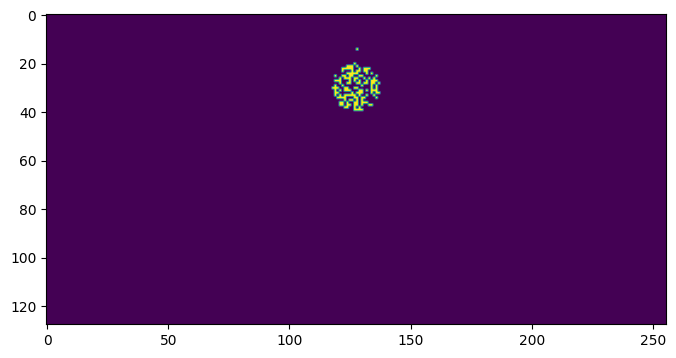

  6%|▋         | 1/16 [00:01<00:26,  1.75s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


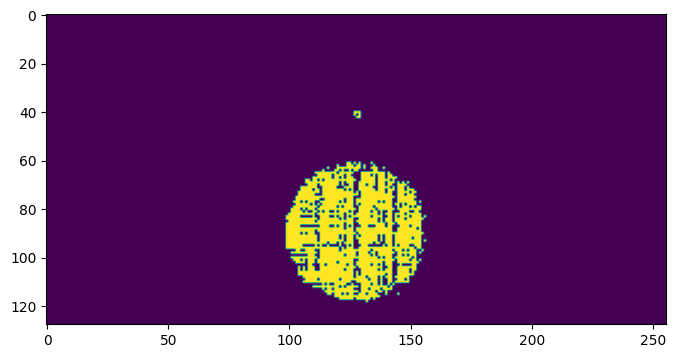

 12%|█▎        | 2/16 [00:03<00:24,  1.74s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


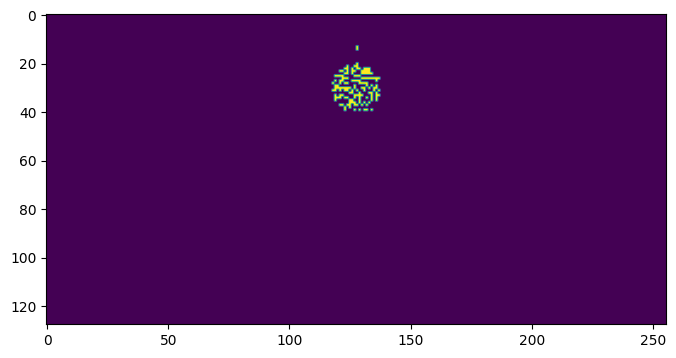

 19%|█▉        | 3/16 [00:05<00:22,  1.75s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


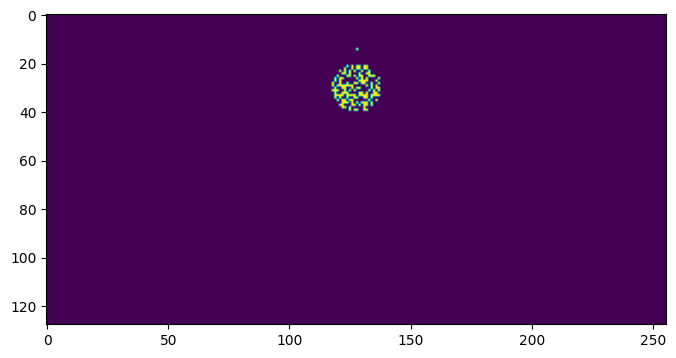

 25%|██▌       | 4/16 [00:06<00:20,  1.75s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


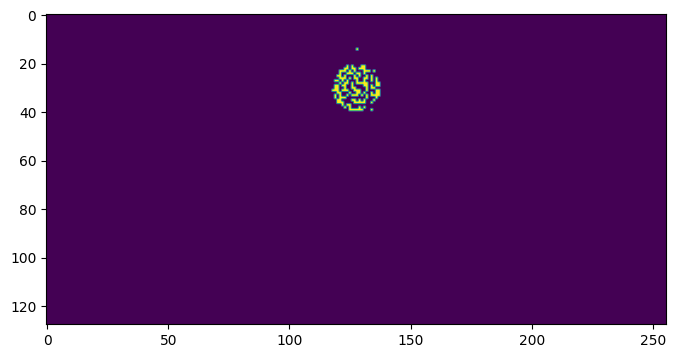

 31%|███▏      | 5/16 [00:08<00:19,  1.76s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


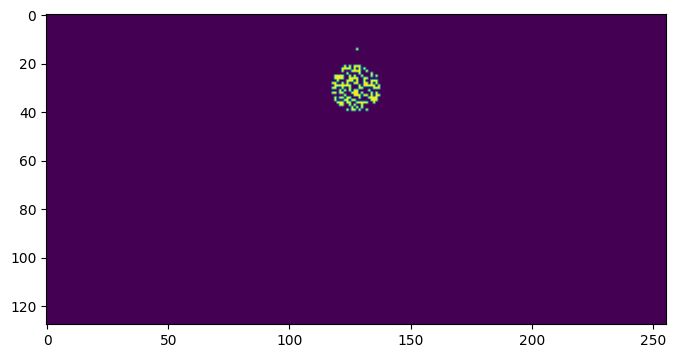

 38%|███▊      | 6/16 [00:10<00:17,  1.77s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


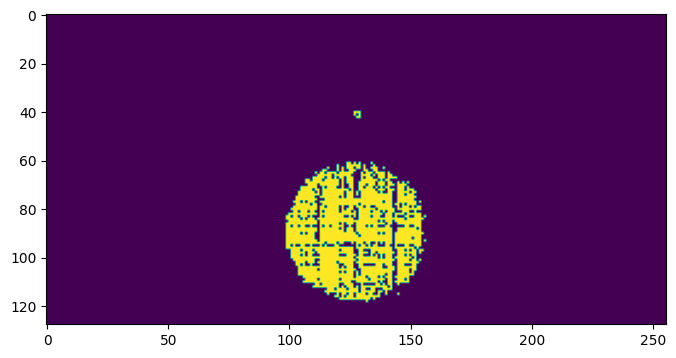

 44%|████▍     | 7/16 [00:12<00:15,  1.77s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


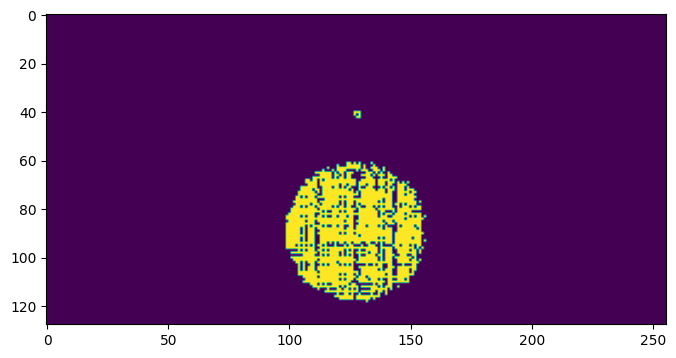

 50%|█████     | 8/16 [00:14<00:14,  1.77s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


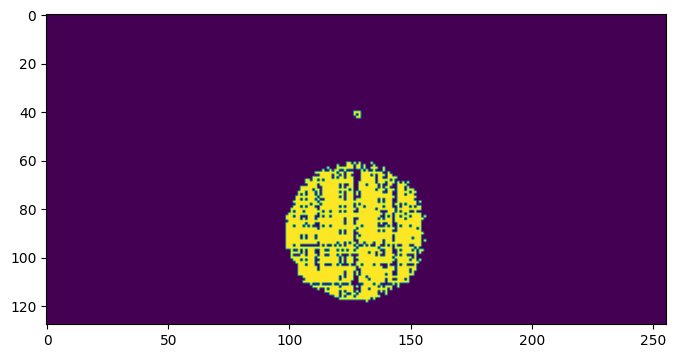

 56%|█████▋    | 9/16 [00:15<00:12,  1.76s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


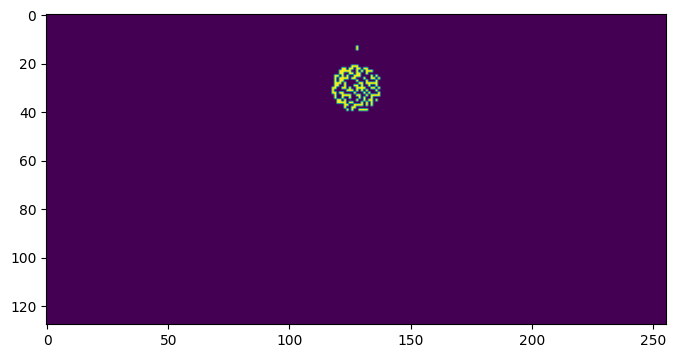

 62%|██████▎   | 10/16 [00:17<00:10,  1.75s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


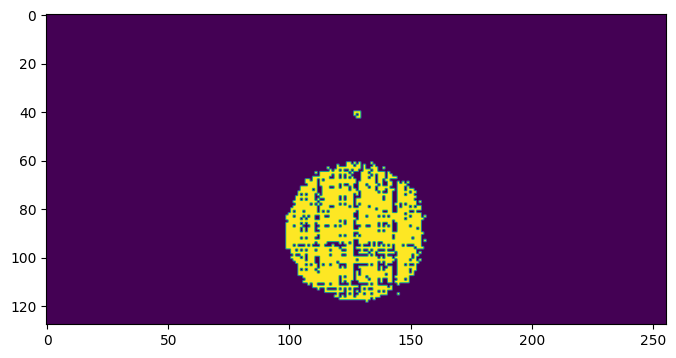

 69%|██████▉   | 11/16 [00:19<00:08,  1.75s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


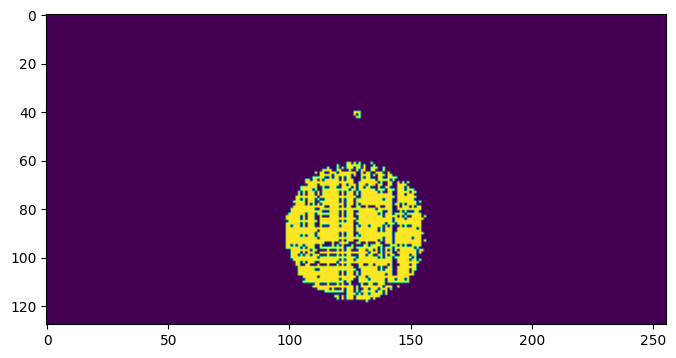

 75%|███████▌  | 12/16 [00:21<00:06,  1.74s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


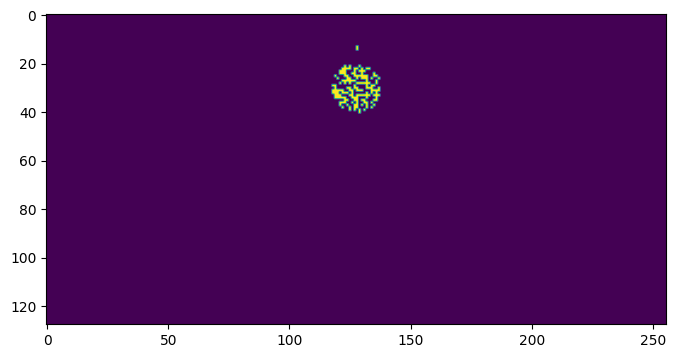

 81%|████████▏ | 13/16 [00:22<00:05,  1.74s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


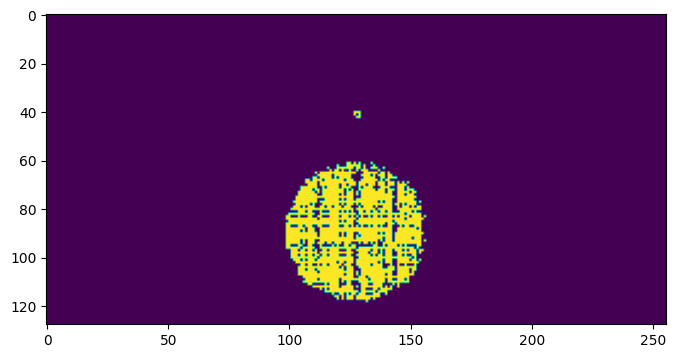

 88%|████████▊ | 14/16 [00:24<00:03,  1.74s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


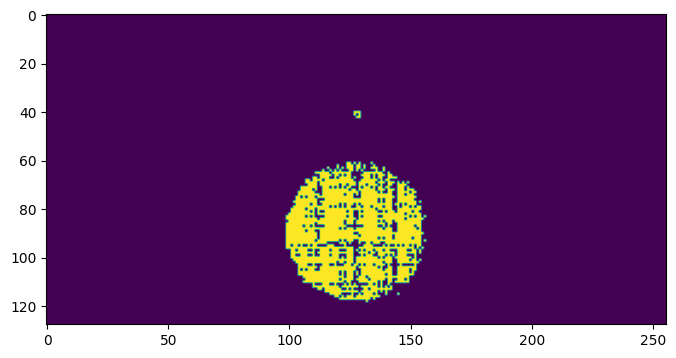

 94%|█████████▍| 15/16 [00:26<00:01,  1.74s/it]

tensor(0., device='cuda:0')
tensor(0.5234, device='cuda:0')
out_batch
tensor(0., device='cuda:0')
tensor(1., device='cuda:0')


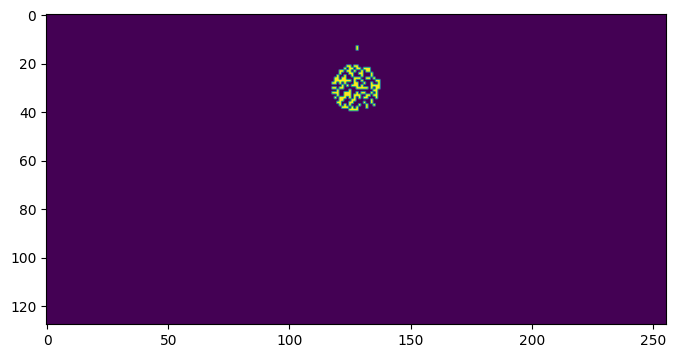

100%|██████████| 16/16 [00:27<00:00,  1.75s/it]

n_epochs: 4 - lr: 0.0001
Dev loss: 543.4141
Speed: 218.71874809265137 ms/sample


In [13]:
import time
%time


n_epochs_list = [4]
lr_list = [1e-4]
batch_size = 8
n = 6
optimizer = None
model = None


train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, num_workers=0, sampler=train_sampler)
dev_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, num_workers=0, sampler=valid_sampler)

fileName = None
dev_history = pd.DataFrame(index=pd.MultiIndex.from_tuples((), names=['epoch', 'lr']), columns=['dev_loss'])

torch.cuda.empty_cache()
gc.collect()

for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        n_epochs = n_epochs_list[i_epoch]
        lr = lr_list[i_lr]
        train_history = pd.DataFrame(index=pd.MultiIndex.from_tuples((), names=['zoom', 'epoch', 'batch_id']), columns=['loss'])

        model = create_model(CAMERA, n)
        if fileName is not None:
            state_dict = torch.load(fileName, map_location='cpu')
            model.load_state_dict(state_dict, strict=False)
            del state_dict
            print("Loaded!!")
        model = model.to(device)

        torch.cuda.empty_cache()

        gc.collect()
        optimizer = optim.SGD(list(model.parameters()), lr=lr)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=.975)

        torch.cuda.empty_cache()
        gc.collect()

        for i in range(1,n+1):
            for epoch in range(n_epochs):
                zoom = n-(i-int(np.random.choice([0,1], size=None, replace=False)))
                torch.cuda.empty_cache()
                gc.collect()

                loader = train_loader
                train_loop_fn(loader, zoom, epoch, train_history)
                
            scheduler.step()

        loader = dev_loader
        start = time.time()*1000.0
        evaluate_model(loader, (n_epochs, lr), dev_history)
        t_interval = time.time()*1000.0 - start
        print("Speed: {} ms/sample".format(t_interval/(len(dev_loader)*batch_size)))

        gc.collect()
        optimizer = None
        gc.collect()

        train_history.to_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        torch.save(model.state_dict(), "./model_{}_{}.pth".format(i_epoch, i_lr))
dev_history.to_csv('dev_history.csv')

# Result Assessment

**Quantification**

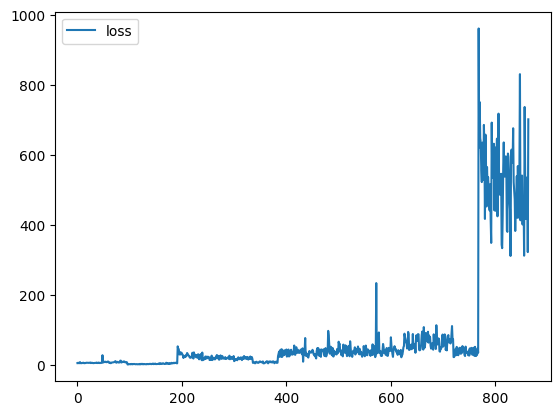

In [14]:
for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        train_history = pd.read_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        train_history[['loss']].plot();

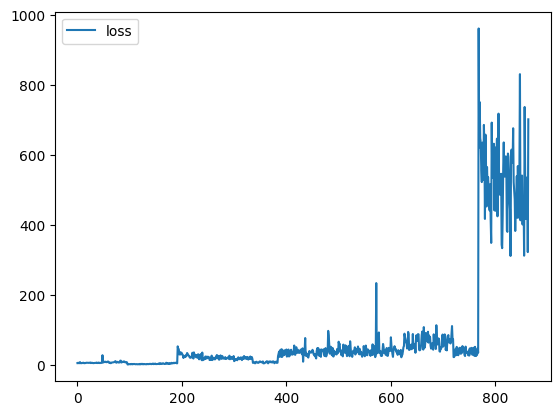

In [15]:
for i_epoch in range(len(n_epochs_list)):
    for i_lr in range(len(lr_list)):
        train_history = pd.read_csv('train_history_{}_{}.csv'.format(i_epoch, i_lr))
        train_history[['loss']].plot();

In [16]:
dev_history

,,dev_loss
epoch,lr,
4,0.0001,543.414062


**Assessing 3D-Model Reconstruction via Output-Target Image Comparison**

  0%|          | 0/16 [00:01<?, ?it/s]


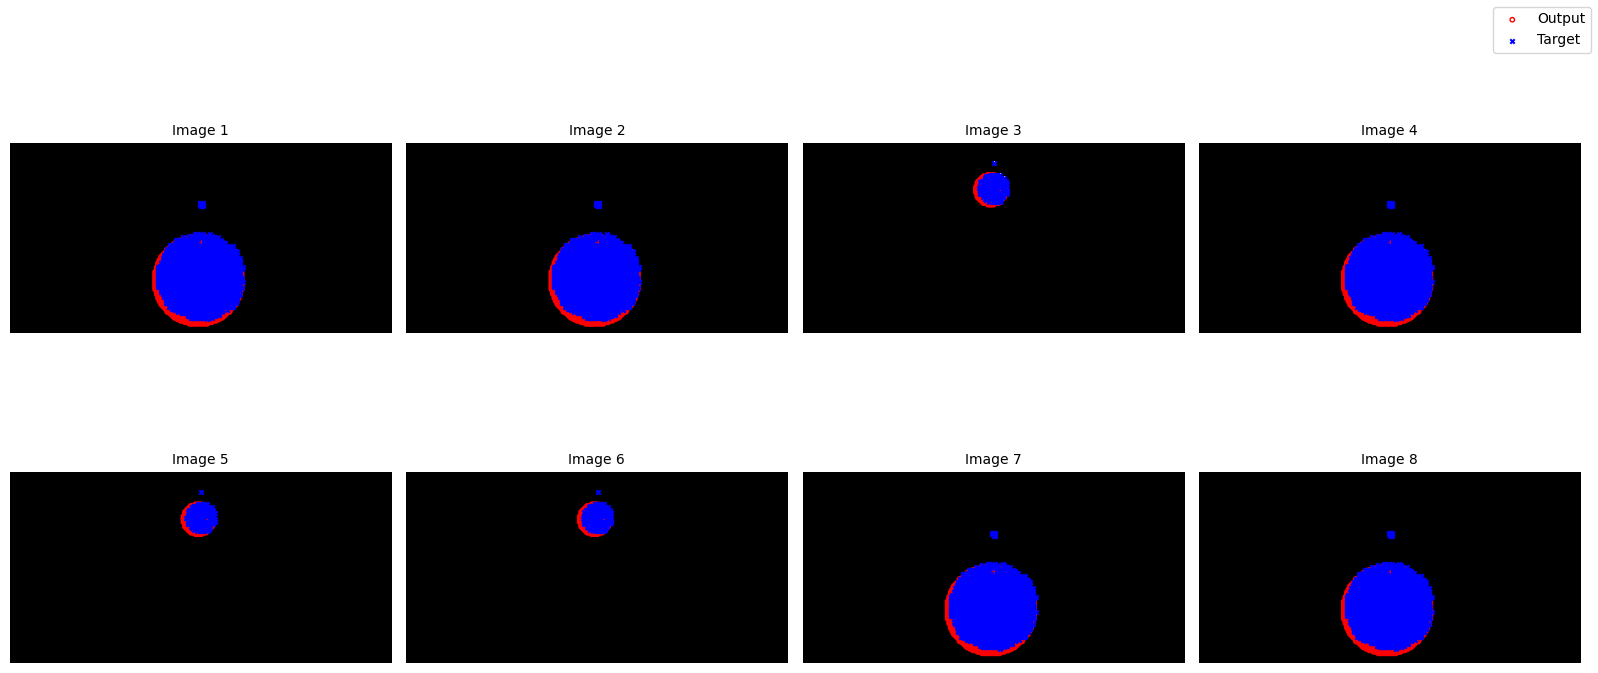

In [17]:
batch_size = 8
valid_sampler = SubsetRandomSampler(valid_idx)
train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, num_workers=0, sampler=train_sampler)
dev_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, num_workers=0, sampler=valid_sampler)
loader = dev_loader
with torch.no_grad():
    for batch_idx, (r_mask_batch, input_2Dr_batch, target_2Dr_batch) in enumerate(tqdm(loader)):
        r_mask_batch, input_2Dr_batch, target_2Dr_batch = r_mask_batch.to(device), input_2Dr_batch.to(device), target_2Dr_batch.to(device)

        weights = model(input_2Dr_batch, r_mask_batch, zoom=0)
        break

# Convert tensors to numpy arrays (make sure they are on CPU)
weights_np = (weights[:,-1,:,:]>specials.OFF_THRESH).float().cpu().numpy()
mask_np = (r_mask_batch[:,0,:,:]).cpu().numpy()
target_np = (target_2Dr_batch[:,0,:,:]).cpu().numpy()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(batch_size):
    ax = axes[i]
    ax.imshow(weights_np[i], cmap='gray', interpolation='nearest', vmin=0, vmax=1)

    out_points = np.argwhere(weights_np[i] > 0)
    target_points = np.argwhere(target_np[i] > 0)

    if target_points.size > 0:
        ax.scatter(target_points[:, 1], target_points[:, 0], facecolors='none',
                   edgecolors='red', s=10, label='Output')

    if out_points.size > 0:
        ax.scatter(out_points[:, 1], out_points[:, 0], marker='x',
                   color='blue', s=10, label='Target')

    ax.set_title(f"Image {i+1}", fontsize=10)
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

**Platonic Representation**

3D Model Mask

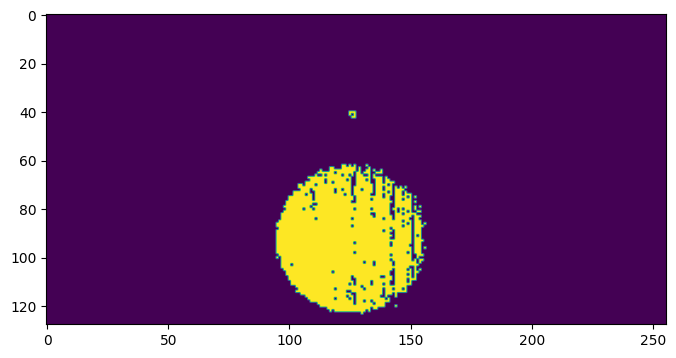

In [18]:
plt.figure(figsize=(8,8))
plt.imshow(((torch.sigmoid(3e-1*model.alice_mask)>0.5).float()[0,:,:,:].permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
plt.show()

3D Model Depth

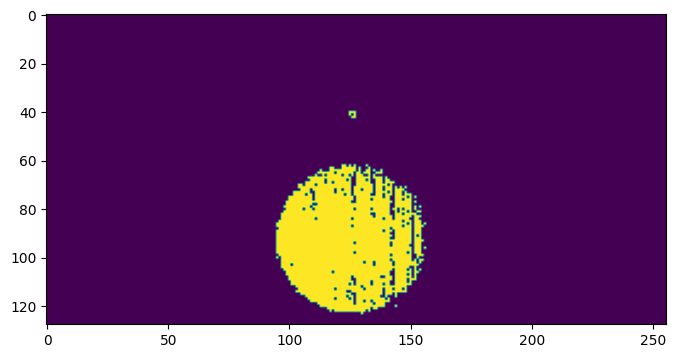

In [19]:
plt.figure(figsize=(8,8))
plt.imshow((((torch.sigmoid(3e-1*model.alice_mask)>0.5).float()*model.alice_z)[0,:,:,:].permute(1,2,0).detach().cpu().numpy()[:,:,-1]).squeeze())
plt.show()